<>:140: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:140: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\alokm\AppData\Local\Temp\ipykernel_9736\106921968.py:140: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  print("  - **Phase:** Shows phase shifts. Phase is cyclical, so 'twilight' colormap helps visualize transitions from $-\pi$ to $\pi$. Sudden color changes can indicate wrapped phase or significant environmental changes.")



--- Processing Moving Room (Data/movingroom.csv) ---
DataFrame head:
          SSID  SubCarrier_index  amplitude  phase  RSSI              BSSID
0  Home 2.4GHz                38      13.04   1.49   -40  5c:64:8e:d0:09:a5
1  Home 2.4GHz                39      12.00   1.57   -40  5c:64:8e:d0:09:a5
2  Home 2.4GHz                40      11.00   1.57   -40  5c:64:8e:d0:09:a5
3  Home 2.4GHz                41       9.06   1.68   -40  5c:64:8e:d0:09:a5
4  Home 2.4GHz                42       7.07   1.71   -40  5c:64:8e:d0:09:a5

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SSID              986 non-null    str    
 1   SubCarrier_index  986 non-null    int64  
 2   amplitude         986 non-null    float64
 3   phase             986 non-null    float64
 4   RSSI              986 non-null    int64  
 5   BSSID             986 non-null

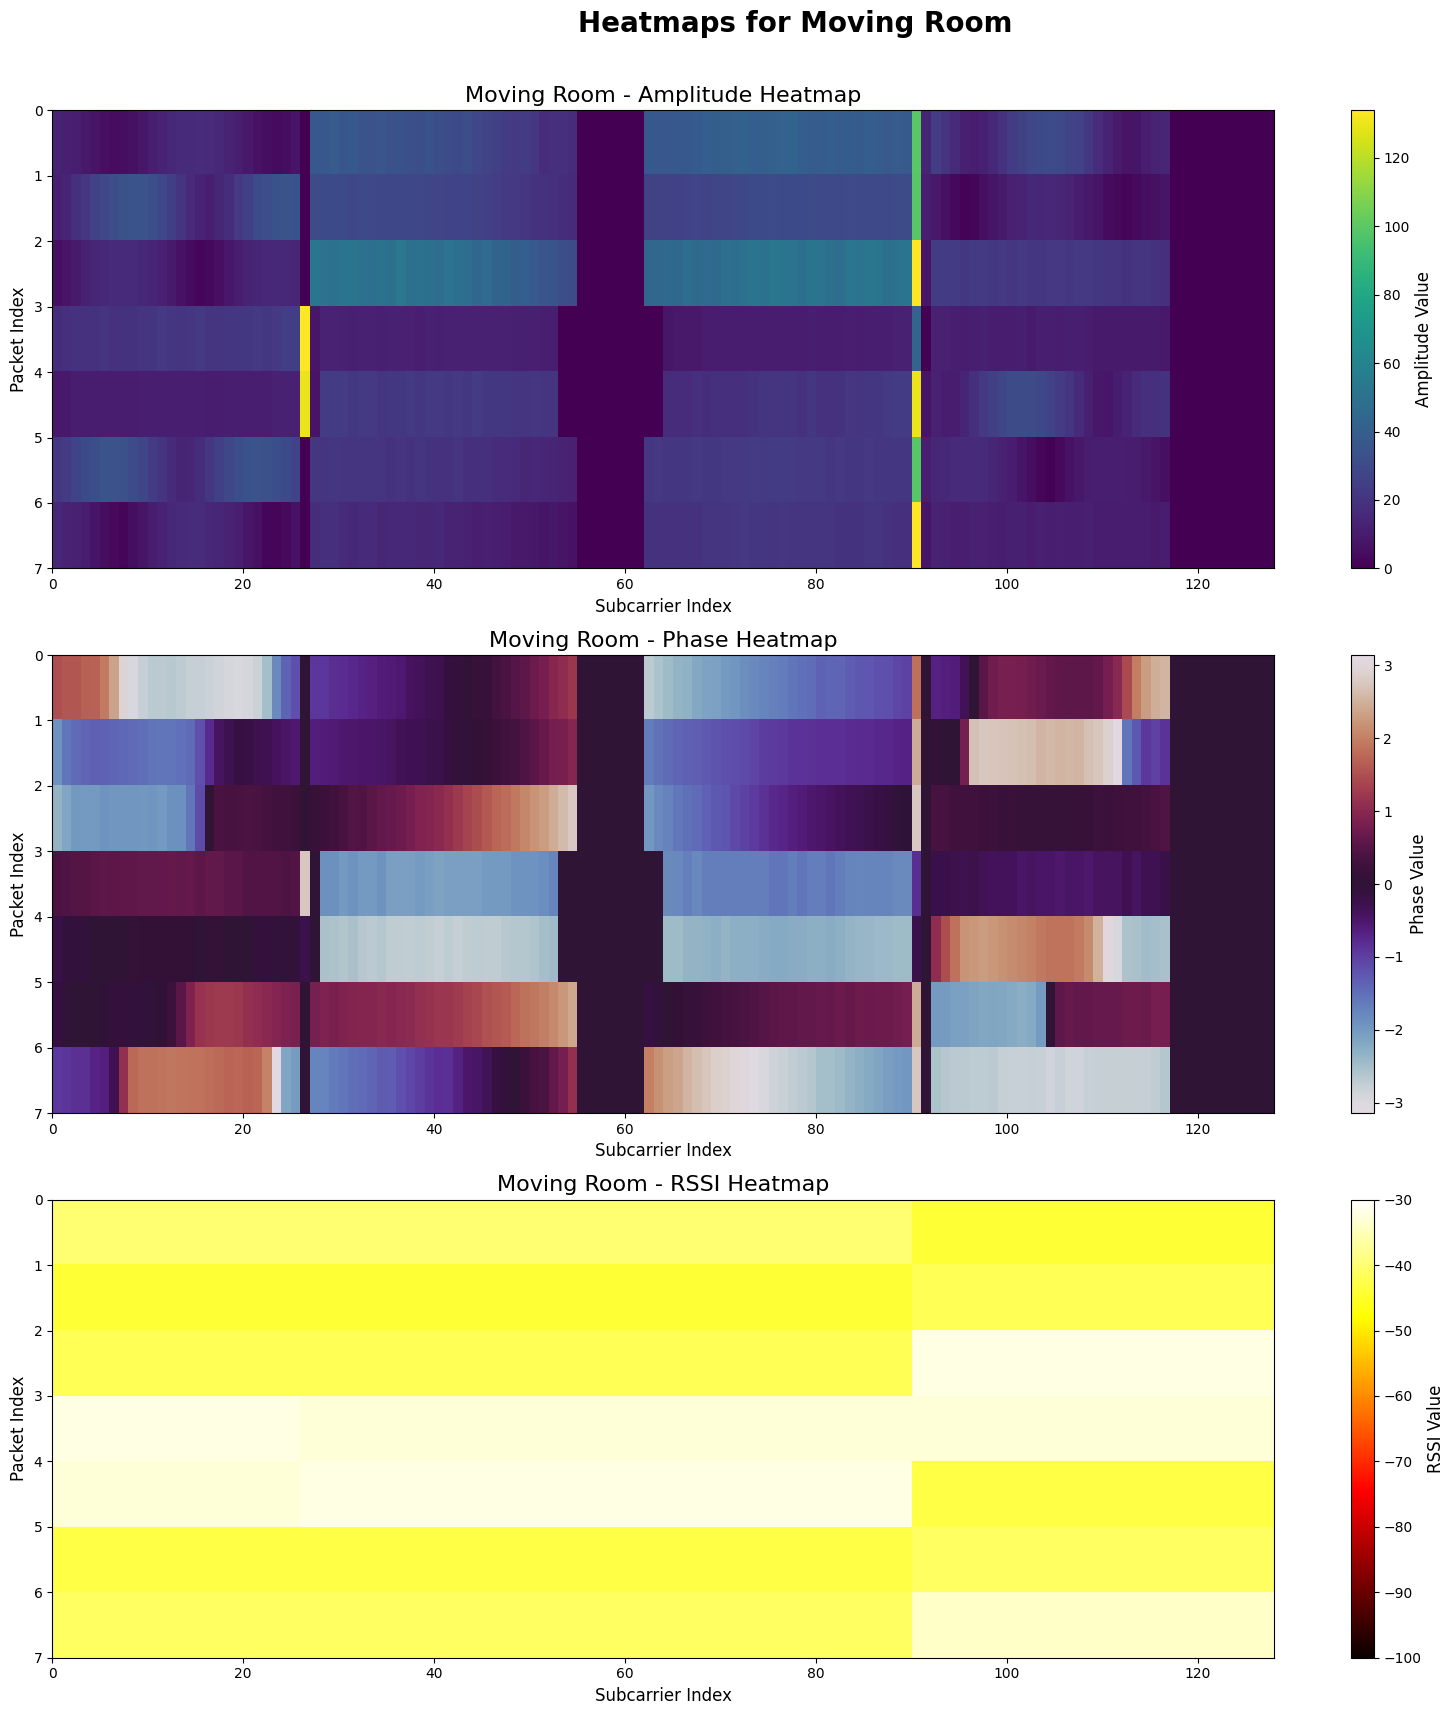


--- Processing Jumping Room (Data/jumpingroom.csv) ---
DataFrame head:
      SSID  SubCarrier_index  amplitude  phase  RSSI              BSSID
0  UNKNOWN                38      19.31  -0.37   -24  58:00:e3:7a:a5:eb
1  UNKNOWN                39      18.97  -0.32   -24  58:00:e3:7a:a5:eb
2  UNKNOWN                40      19.65  -0.26   -24  58:00:e3:7a:a5:eb
3  UNKNOWN                41      20.62  -0.24   -24  58:00:e3:7a:a5:eb
4  UNKNOWN                42      20.62  -0.24   -24  58:00:e3:7a:a5:eb

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SSID              985 non-null    str    
 1   SubCarrier_index  985 non-null    int64  
 2   amplitude         985 non-null    float64
 3   phase             985 non-null    float64
 4   RSSI              985 non-null    int64  
 5   BSSID             985 non-null    str    
dtypes: fl

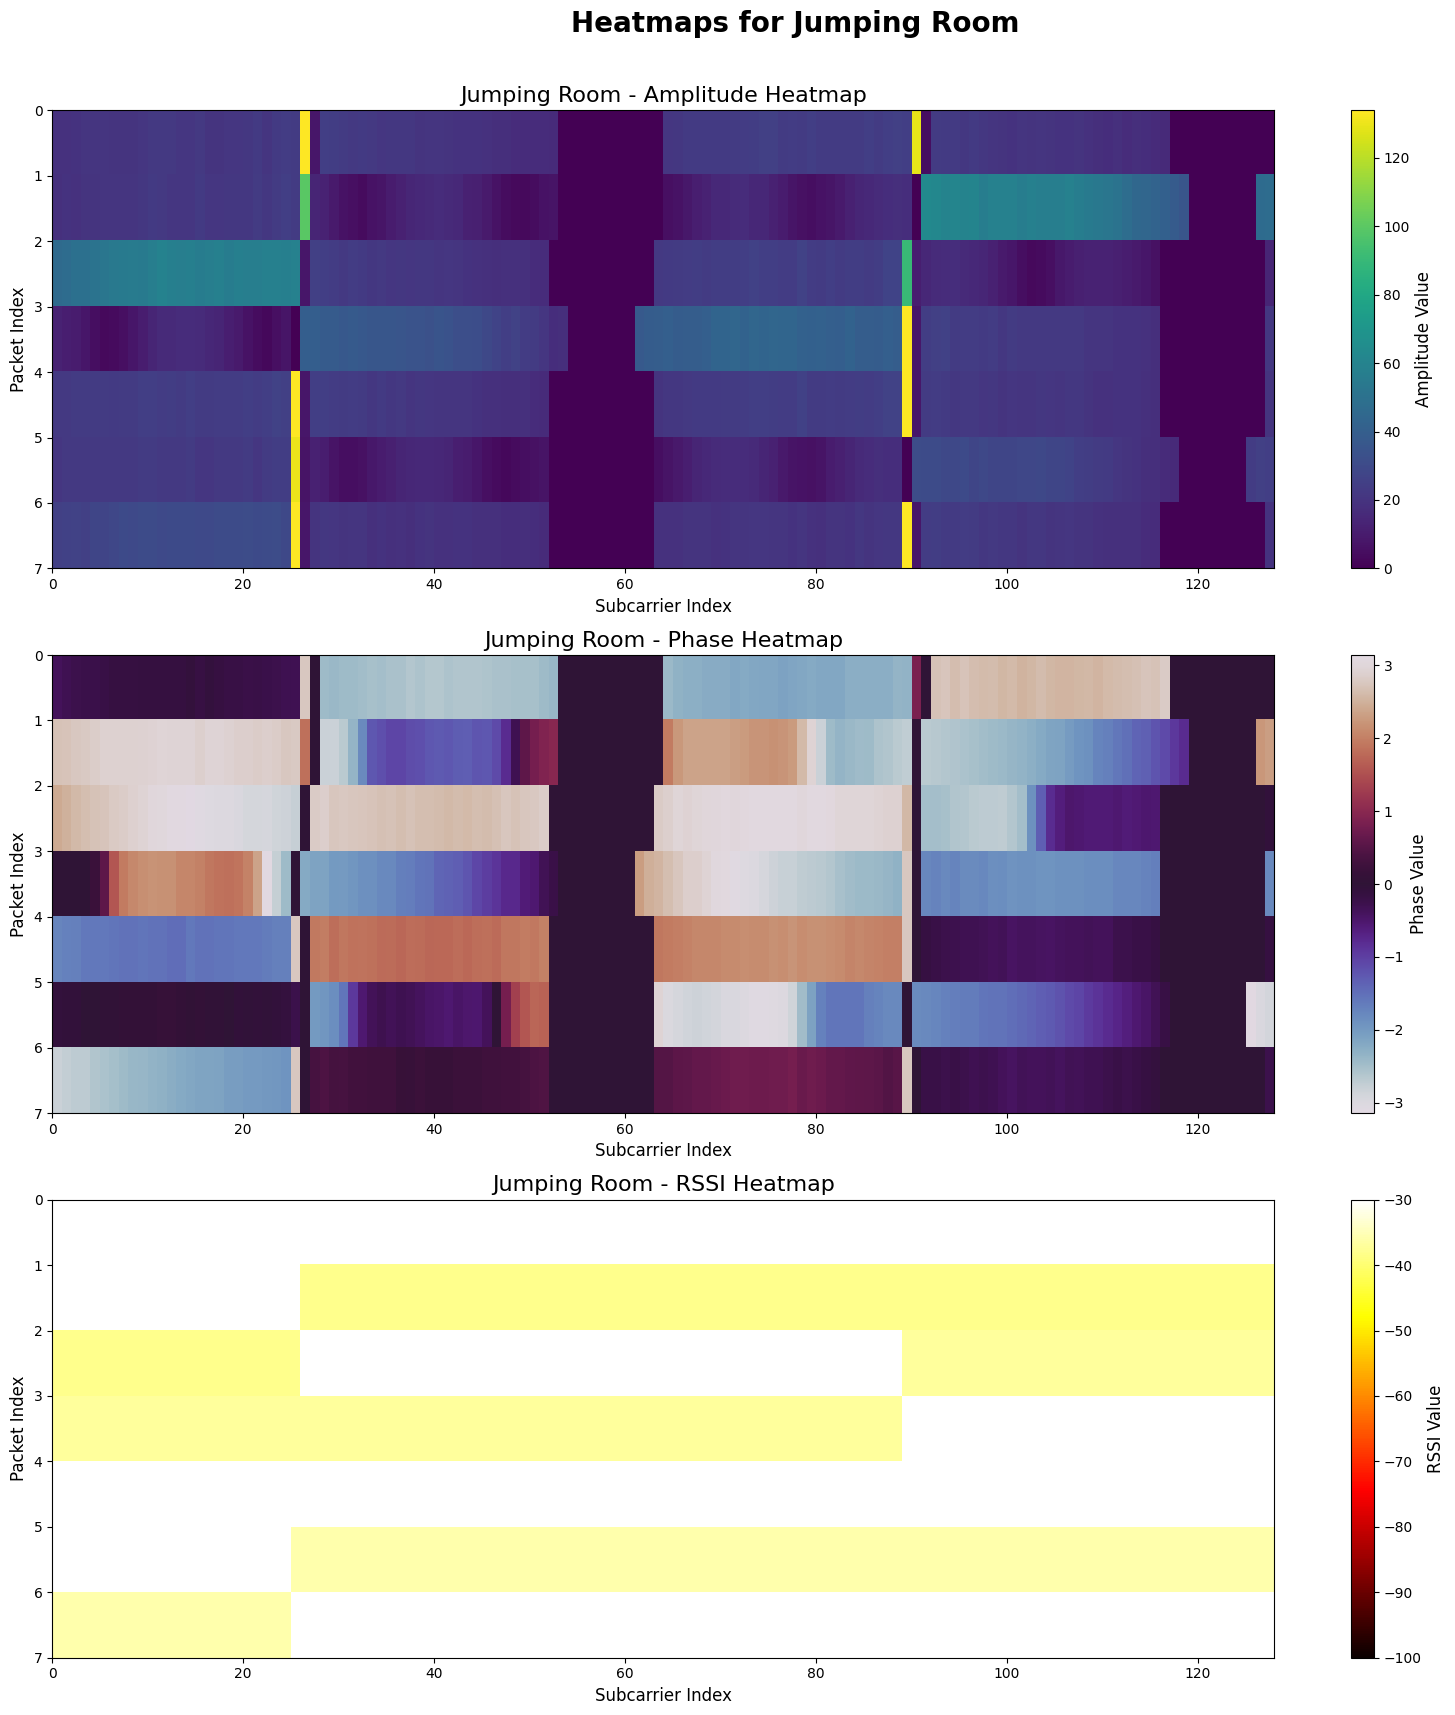


--- Processing Still Room (Data/stillroom.csv) ---
DataFrame head:
          SSID  SubCarrier_index  amplitude  phase  RSSI              BSSID
0  Home 2.4GHz                38       8.06  -2.62   -45  5c:64:8e:d0:09:a5
1  Home 2.4GHz                39      14.21  -2.46   -45  5c:64:8e:d0:09:a5
2  Home 2.4GHz                40      18.38  -2.36   -45  5c:64:8e:d0:09:a5
3  Home 2.4GHz                41      24.04  -2.36   -45  5c:64:8e:d0:09:a5
4  Home 2.4GHz                42      27.59  -2.33   -45  5c:64:8e:d0:09:a5

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SSID              986 non-null    str    
 1   SubCarrier_index  986 non-null    int64  
 2   amplitude         986 non-null    float64
 3   phase             986 non-null    float64
 4   RSSI              986 non-null    int64  
 5   BSSID             986 non-null  

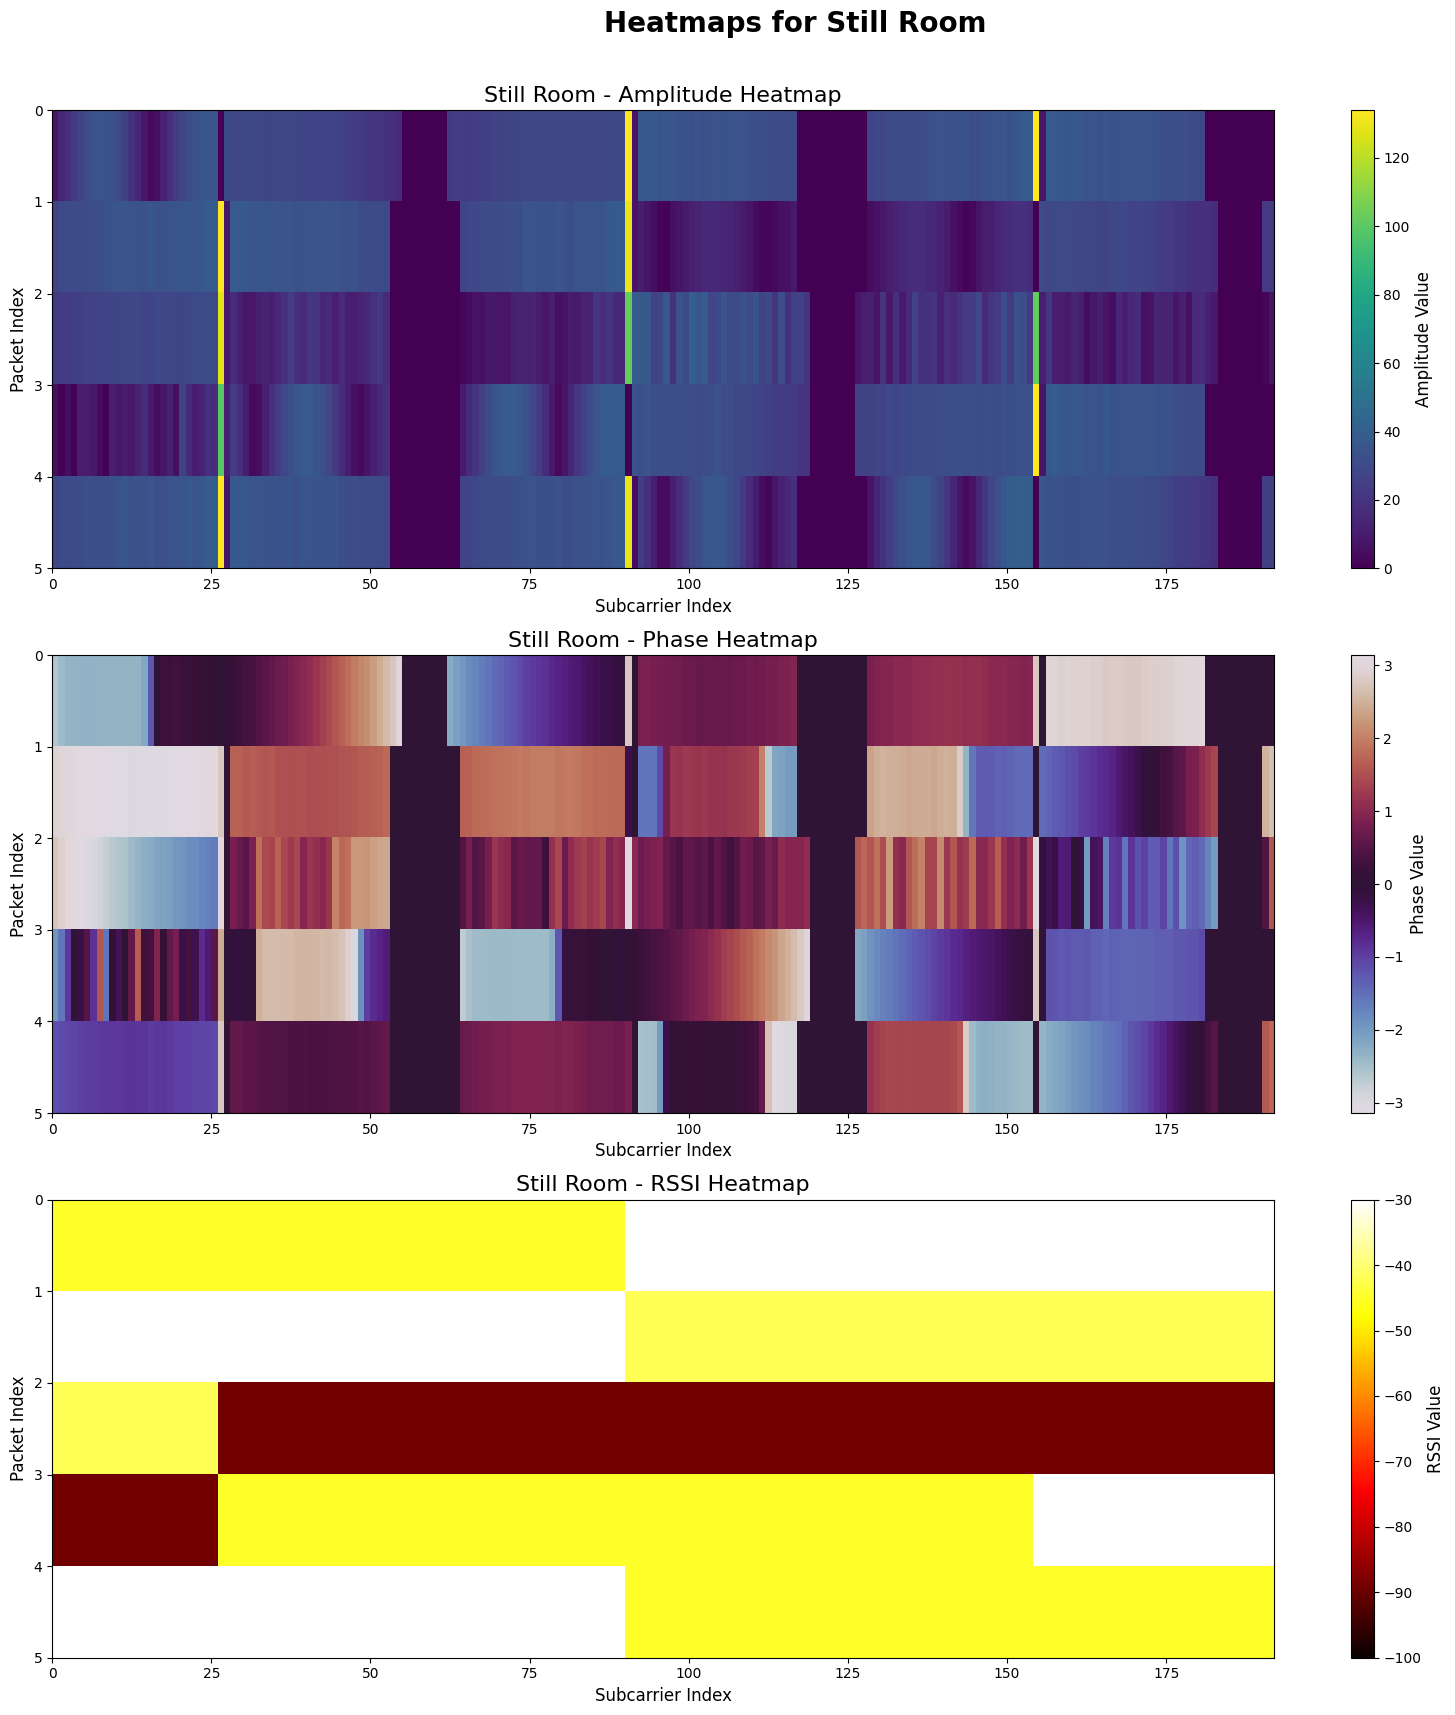


--- Heatmap Interpretation Notes ---
Each heatmap visualizes a different CSI metric (Amplitude, Phase, RSSI) over time and subcarriers.
- **X-axis (Subcarrier Index):** Represents the individual Wi-Fi subcarriers (frequency bins).
- **Y-axis (Packet Index):** Represents the sequence of Wi-Fi packets/CSI measurements over time.
- **Color:** Indicates the value of the respective metric. The color bar shows the mapping.
  - **Amplitude:** Shows signal strength per subcarrier. Higher values (brighter colors for viridis) mean stronger signals.
  - **Phase:** Shows phase shifts. Phase is cyclical, so 'twilight' colormap helps visualize transitions from $-\pi$ to $\pi$. Sudden color changes can indicate wrapped phase or significant environmental changes.
  - **RSSI:** Shows overall signal strength, less granular than amplitude. Often useful for identifying periods of strong/weak signal reception.

Variations in these heatmaps can reveal patterns related to movement, breathing, object detecti

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('Dependencies'))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math # For math.pi

# --- Instructions for Google Colab ---
# 1. Put movingroom.csv, jumpingroom.csv, and stillroom.csv in the Data folder.
#    Then click the "Upload to session storage" icon (looks like a page with an arrow pointing up).

# Define the file paths for your uploaded CSVs
file_paths = {
    "Moving Room": "Data/movingroom.csv",
    "Jumping Room": "Data/jumpingroom.csv",
    "Still Room": "Data/stillroom.csv"
}

# Metrics to visualize as heatmaps
# CORRECTED COLUMN NAMES based on your CSV data
heatmap_metrics = ['amplitude', 'phase', 'RSSI']

# Loop through each scenario (file) to read data and plot heatmaps
for i, (label, path) in enumerate(file_paths.items()):
    print(f"\n--- Processing {label} ({path}) ---")
    try:
        df = pd.read_csv(path)

        # --- DEBUGGING PRINTS (Retained for initial data inspection) ---
        print("DataFrame head:")
        print(df.head())
        print("\nDataFrame info:")
        df.info()
        print("---------------------------------------")
        # --- END DEBUGGING PRINTS ---

        # Check for required columns - CORRECTED TO MATCH CSV
        required_cols = ['SubCarrier_index'] + heatmap_metrics
        missing_cols = [col for col in required_cols if col not in df.columns]

        if missing_cols:
            print(f"Error: Missing columns in {path}: {', '.join(missing_cols)}. Available columns: {df.columns.tolist()}")
            continue # Skip to the next file

        # Infer the number of subcarriers per packet
        # Assumes SubCarrier_index is 0-indexed and continuous within a packet
        # CORRECTED COLUMN NAME
        n_subcarriers = df['SubCarrier_index'].max() + 1
        print(f"Inferred number of subcarriers per packet: {n_subcarriers}")

        if n_subcarriers == 0:
            print(f"Warning: No subcarrier data found or SubCarrier_index is 0 in {path}. Skipping heatmaps.")
            continue

        # Filter out rows that are not part of a complete packet
        num_rows = len(df)
        num_complete_packets = num_rows // n_subcarriers

        if num_complete_packets == 0:
            print(f"Warning: Not enough data for at least one complete packet ({num_rows} rows, {n_subcarriers} subcarriers expected). Skipping heatmaps for {label}.")
            continue

        # Slice the DataFrame to only include full packets
        df_reshaped = df.iloc[:num_complete_packets * n_subcarriers]

        # Create a figure for heatmaps of the current file
        fig_hm, axes_hm = plt.subplots(len(heatmap_metrics), 1, figsize=(16, 6 * len(heatmap_metrics)), sharex=False)
        fig_hm.suptitle(f'Heatmaps for {label}', fontsize=20, fontweight='bold')

        # Ensure axes_hm is iterable even for a single subplot
        if len(heatmap_metrics) == 1:
            axes_hm = [axes_hm]

        for j, metric in enumerate(heatmap_metrics):
            data_to_plot = df_reshaped[metric].values

            # Handle potential empty or NaN data for the metric
            if data_to_plot.size == 0 or np.all(np.isnan(data_to_plot)):
                axes_hm[j].text(0.5, 0.5, f"No valid {metric} data found in '{label}' file for heatmap.",
                                horizontalalignment='center', verticalalignment='center',
                                transform=axes_hm[j].transAxes, color='orange', fontsize=14)
                print(f"Warning: '{metric}' column in {path} is empty or contains only NaN values after reshaping.")
                continue

            # Reshape the data into (packets, subcarriers)
            # The order in CSV is typically subcarrier 0 for packet 0, then subcarrier 1 for packet 0, etc.
            # So, reshape needs to be done carefully based on how your data was logged.
            # Assuming consecutive subcarriers for a single packet are contiguous in the CSV:
            reshaped_matrix = data_to_plot.reshape(num_complete_packets, n_subcarriers)

            # Define value ranges for color mapping (optional, but good for consistency)
            if metric == 'phase': # Corrected metric name
                vmin, vmax = -math.pi, math.pi
                cmap = 'twilight' # Cyclical colormap for phase
            elif metric == 'amplitude': # Corrected metric name
                vmin, vmax = None, None # Let matplotlib auto-scale
                cmap = 'viridis'
            elif metric == 'RSSI':
                vmin, vmax = -100, -30 # Typical RSSI range
                cmap = 'hot'
            else:
                vmin, vmax = None, None
                cmap = 'viridis'

            # Create the heatmap
            im = axes_hm[j].imshow(reshaped_matrix, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                                    extent=[0, n_subcarriers, num_complete_packets, 0]) # extent for correct axis labels

            # Use proper capitalization for display titles
            display_metric_name = metric.capitalize() if metric != 'RSSI' else metric # Keep RSSI as is
            axes_hm[j].set_title(f'{label} - {display_metric_name} Heatmap', fontsize=16)
            axes_hm[j].set_xlabel('Subcarrier Index', fontsize=12)
            axes_hm[j].set_ylabel('Packet Index', fontsize=12)

            # Add a colorbar
            cbar = fig_hm.colorbar(im, ax=axes_hm[j])
            cbar.set_label(f'{display_metric_name} Value', fontsize=12)

            # Set y-axis ticks for clarity (e.g., 0, 100, 200 packets)
            if num_complete_packets > 10: # Only set explicit ticks if there are many packets
                 axes_hm[j].set_yticks(np.linspace(0, num_complete_packets, min(5, num_complete_packets // 10 + 2)).astype(int))


        plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect for suptitle
        plt.show()

    except FileNotFoundError:
        print(f"Error: File not found at {path}. Please ensure it is uploaded to Colab.")
    except Exception as e:
        print(f"An unexpected error occurred while processing {path}: {e}")

print("\n--- Heatmap Interpretation Notes ---")
print("Each heatmap visualizes a different CSI metric (Amplitude, Phase, RSSI) over time and subcarriers.")
print("- **X-axis (Subcarrier Index):** Represents the individual Wi-Fi subcarriers (frequency bins).")
print("- **Y-axis (Packet Index):** Represents the sequence of Wi-Fi packets/CSI measurements over time.")
print("- **Color:** Indicates the value of the respective metric. The color bar shows the mapping.")
print("  - **Amplitude:** Shows signal strength per subcarrier. Higher values (brighter colors for viridis) mean stronger signals.")
print("  - **Phase:** Shows phase shifts. Phase is cyclical, so 'twilight' colormap helps visualize transitions from $-\pi$ to $\pi$. Sudden color changes can indicate wrapped phase or significant environmental changes.")
print("  - **RSSI:** Shows overall signal strength, less granular than amplitude. Often useful for identifying periods of strong/weak signal reception.")
print("\nVariations in these heatmaps can reveal patterns related to movement, breathing, object detection, etc.")
